# Imports, Setup and Functions

In [422]:
import json
import tabulate
import matplotlib
import numpy as np
from pathlib import Path
from itertools import cycle
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.interpolate import interp1d
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

matplotlib.rcParams.update({
    'font.size': 14,
    'figure.figsize': (10, 6),
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'axes.grid': True,
    'savefig.format': 'pdf',
    'legend.facecolor': 'snow',
})

cwd = Path.cwd()
fig_dir = cwd / 'figs'

In [423]:
@dataclass
class TALYS_data:
    path: Path
    
    

def read_exfor_data(file_path: str | Path) -> dict[str, dict[str, float]]:
    """
    Reads EXFOR data from a JSON file and stores it in a structured dictionary.
    
    Parameters
    ----------
    file_path : str | Path
        Path to the JSON file containing EXFOR data.
    
    Returns
    ------- 
    dict[str, dict[str, float]]
        A dictionary where each key is an author's name and the value is another dictionary
        containing arrays for 'x', 'y', 'dy', and 'dx' data.
        
        x:  Energy values (MeV)
        
        y:  Cross section values (mb)
        
        dy: Uncertainties in y (mb)
        
        dx: Uncertainties in x (MeV)
    """
    with open(file_path) as file:
        exfor = json.load(file)
    
    data_exfor = {}
    for funcs in exfor['funcs']:
        data_set = funcs['pts']
        for entry in data_set:
            author = entry['a1']
            if author not in data_exfor:
                data_exfor[author] = {'x': [], 'y': [], 'dy': [], 'dx': []}
                
            data_exfor[author]['x'].append(entry['x'])
            data_exfor[author]['y'].append(entry['y'])
            
            if 'dy' in entry:
                data_exfor[author]['dy'].append(entry['dy']) 
            else:
                data_exfor[author]['dy'].append(np.nan)
            
            if 'dx' in entry:
                data_exfor[author]['dx'].append(entry['dx']) 
            else:
                data_exfor[author]['dx'].append(np.nan)
                
    for author in data_exfor:
        data_exfor[author]['x'] =     np.array(data_exfor[author]['x'])
        data_exfor[author]['y'] = 1e3*np.array(data_exfor[author]['y'])
        
        data_exfor[author]['dx'] = np.ma.masked_invalid(    np.array(data_exfor[author]['dx']))
        data_exfor[author]['dy'] = np.ma.masked_invalid(1e3*np.array(data_exfor[author]['dy']))
        
    return data_exfor

def plot_exfor_data(exfor_data: dict[str, dict[str, float]], face_alpha: float = 1, border_alpha: float = 1) -> None:
    """
    Plots EXFOR data from dict returned by `read_exfor_data()`. 
    
    Parameters
    ----------
    exfor_data : dict[str, dict[str, float]]
        A dictionary where each key is an author's name and the value is another dictionary containing arrays for 'x', 'y', 'dy', and 'dx' data.
        
        x:  Energy values (MeV)\n    
        y:  Cross section values (mb)\n    
        dy: Uncertainties in y (mb)\n    
        dx: Uncertainties in x (MeV)\n    
    face_alpha : float, optional
        Alpha value for the face of the markers (default is 1).
    border_alpha : float, optional
        Alpha value for the border of the markers (default is 1).
    """
    
    
    formats = cycle(['o', 's', '^', 'v', '<', '>', '*'])
    colors = cycle(plt.get_cmap("Set1").colors) # type: ignore
    for author in exfor_data: 
        x  = exfor_data[author]['x']
        y  = exfor_data[author]['y']
        dy = exfor_data[author]['dy']
        dx = exfor_data[author]['dx']
        
        color  = next(colors)
        format = next(formats)
        plt.errorbar(x, y, yerr=dy, xerr=dx, fmt=format, color=color, label=author, zorder=2, alpha=face_alpha, capsize=2)
        
        # Plot twice as scatter to add thicker edge
        plt.scatter(x, y, edgecolor=(0,0,0,border_alpha), facecolor=(0,0,0,0), marker=format, zorder=3)
        
def plot_TALYS_data(file_path: str | Path, title: str, color: str | tuple[int, int, int] = 'lime', linestyle: str = '-', zorder: int = 3, logx: bool = False, logy: bool = True) -> None:
    """
    Plots TALYS data from a given file.
    
    Parameters
    ----------
    file_path : str | Path
        Path to the TALYS data file.
    title : str
        Title for the plot.
    color : str | tuple[int, int, int]
        Color for the plot line.
    linestyle : str, optional
        Line style for the plot (default is '-').
    zorder : int, optional
        Z-order for the plot (default is 3).
    logx : bool, optional
        Whether to use logarithmic scale for x-axis (default is False).
    logy : bool, optional
        Whether to use logarithmic scale for y-axis (default is True).
    """
    data = np.loadtxt(file_path, comments='#')
    E  = data[:, 0]
    CS = data[:, 1]
    
    plt.plot(E, CS, label='TALYS', color=color, linestyle=linestyle, zorder=zorder)
    
    plt.xlabel('Energy [MeV]')
    plt.ylabel('Cross Section [mb]')
    if logx:
        plt.xscale('log')
    if logy:
        plt.yscale('log')
    plt.title(title)
    
    plt.legend()

# Example 1

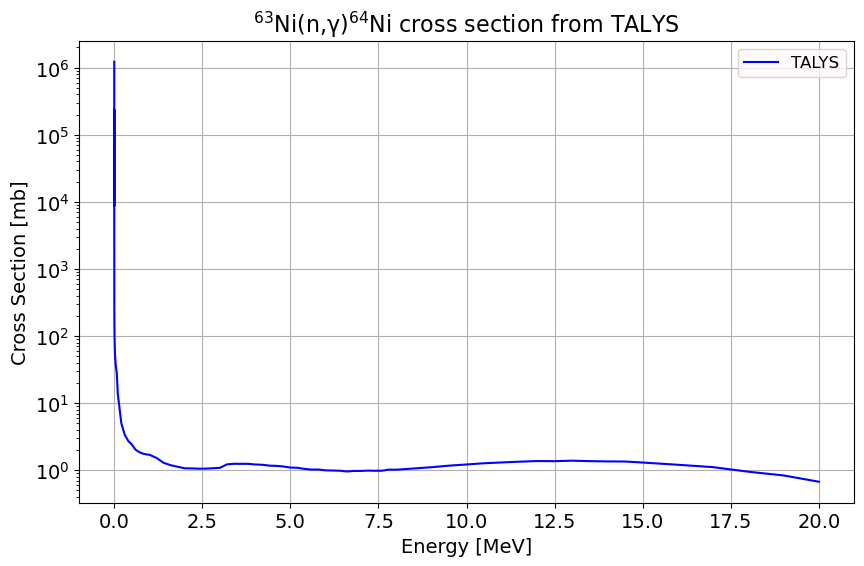

In [424]:
# Ni63_n_γ_data = np.loadtxt(Ni63_n_γ)

# Ni63_n_γ_data_E  = Ni63_n_γ_data[:, 0]
# Ni63_n_γ_data_CS = Ni63_n_γ_data[:, 1]

# plt.plot(Ni63_n_γ_data_E, Ni63_n_γ_data_CS, label='63Ni(n,γ)64Ni')

# plt.semilogy()

# plt.xlabel('Energy [MeV]')
# plt.ylabel('Cross section [mb]')

# plt.legend()

Ni63_n_γ = cwd / 'SimpleExampleEnergyGrid/rp028064.tot'
plot_TALYS_data(Ni63_n_γ, title=r"$^{63}$Ni(n,γ)$^{64}$Ni cross section from TALYS", color='blue')

plt.show()

# Exercise 1

## $^{191}\text{Os}$

### $(n,γ)$

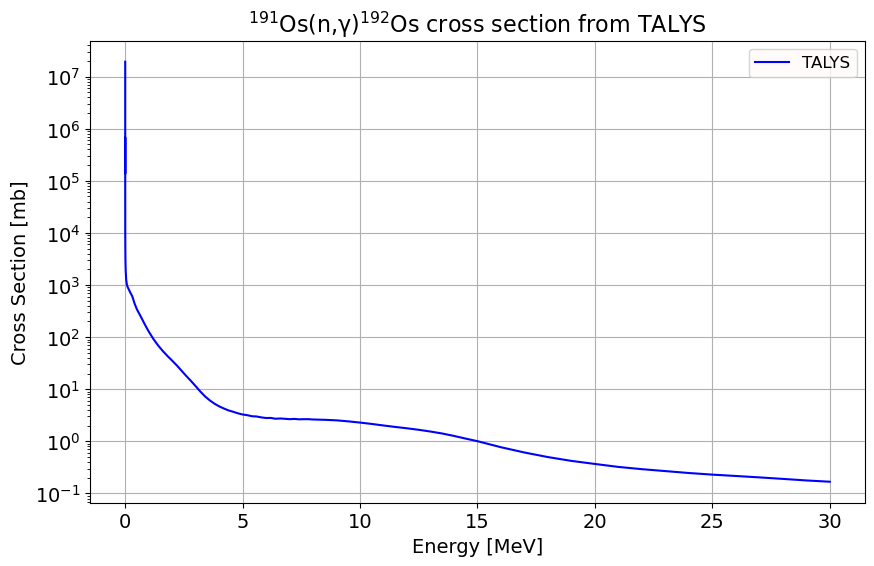

In [425]:
# Os191_n_γ_data = np.loadtxt(Os191_n_γ)

# Os191_n_γ_E  = Os191_n_γ_data[:, 0]
# Os191_n_γ_CS = Os191_n_γ_data[:, 1]

# plt.plot(Os191_n_γ_E, Os191_n_γ_CS, label='191Os(n,γ)192Os')

# # plt.semilogx()
# plt.semilogy()

# plt.xlabel('Energy [MeV]')
# plt.ylabel('Cross section [mb]')

# plt.title(r"$^{191}$Os(n,γ)$^{192}$Os cross sections from TALYS")

# plt.savefig(fig_dir / 'Os191_n_gamma_cross_section')

Os191_n_γ = cwd / 'Os191/default/rp076192.tot'
plot_TALYS_data(Os191_n_γ, title=r"$^{191}$Os(n,γ)$^{192}$Os cross section from TALYS", color='blue')

plt.savefig(fig_dir / 'Os191_n_gamma_cross_section')
plt.show()

### $(n, n')$

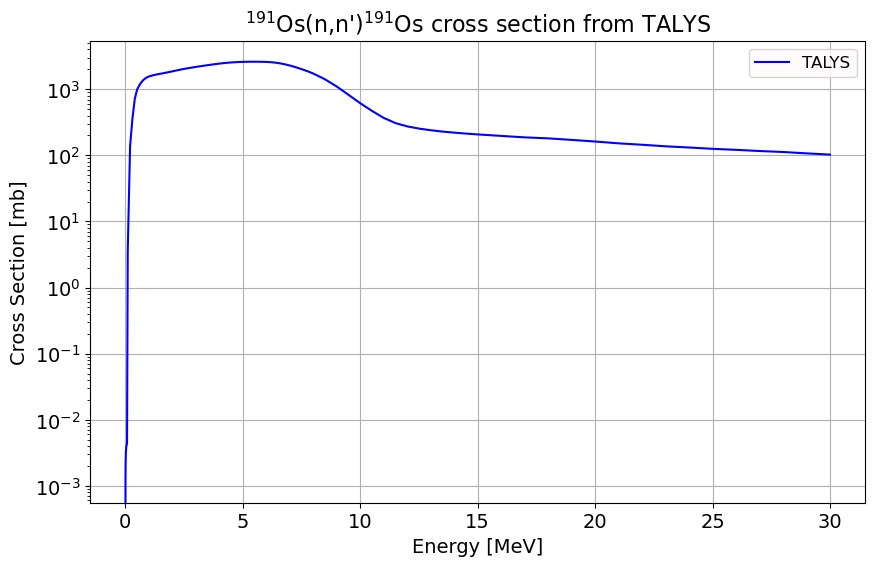

In [426]:
# Os191_n_nprime_data = np.loadtxt(Os191_n_nprime)

# Os191_n_nprime_E  = Os191_n_nprime_data[:, 0]
# Os191_n_nprime_CS = Os191_n_nprime_data[:, 1]

# plt.plot(Os191_n_nprime_E, Os191_n_nprime_CS)

# # plt.semilogx()
# plt.semilogy()

# plt.xlabel('Energy [MeV]')
# plt.ylabel('Cross section [mb]')

# plt.title(r"$^{191}$Os(n,n')$^{191}$Os cross sections from TALYS")
Os191_n_nprime = cwd / 'Os191/default/rp076191.tot'
plot_TALYS_data(Os191_n_nprime, title=r"$^{191}$Os(n,n')$^{191}$Os cross section from TALYS", color='blue')

plt.savefig(fig_dir / 'Os191_n_nprime_cross_section')
plt.show()

## $^{191}\text{Re}$

### $(p, γ)$

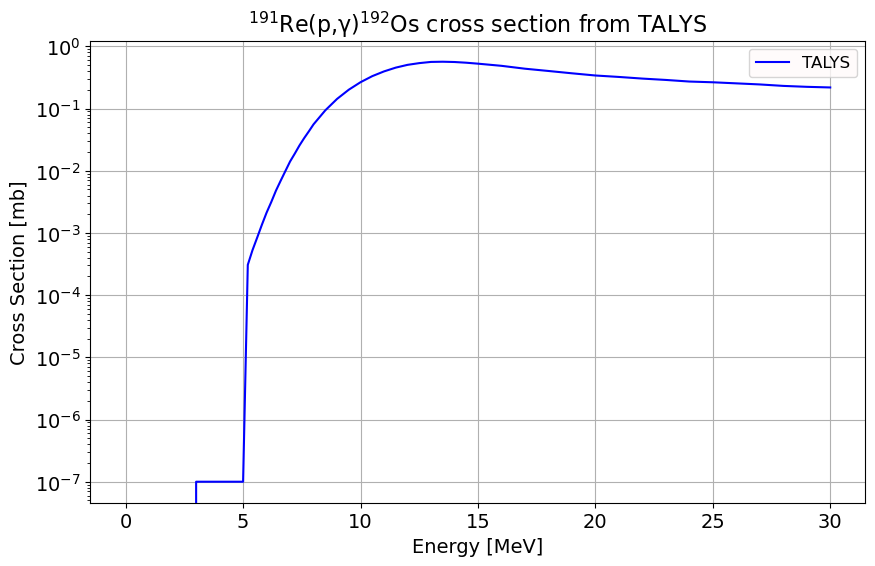

In [427]:
# Re191_p_γ_data = np.loadtxt(Re191_p_γ)

# Re191_p_γ_E  = Re191_p_γ_data[:, 0]
# Re191_p_γ_CS = Re191_p_γ_data[:, 1]

# plt.plot(Re191_p_γ_E, Re191_p_γ_CS)

# # plt.semilogx()
# plt.semilogy()

# plt.xlabel('Energy [MeV]') 
# plt.ylabel('Cross section [mb]')

# plt.title(r"$^{191}$Re(p,γ)$^{192}$Os cross section from TALYS")
Re191_p_γ = cwd / 'Re191/rp076192.tot'
plot_TALYS_data(Re191_p_γ, title=r"$^{191}$Re(p,γ)$^{192}$Os cross section from TALYS", color='blue')

plt.savefig(fig_dir / 'Re191_p_gamma_cross_section')
plt.show()

# Example 2

## $^{90}\text{Zr}$

### $(n, γ)$

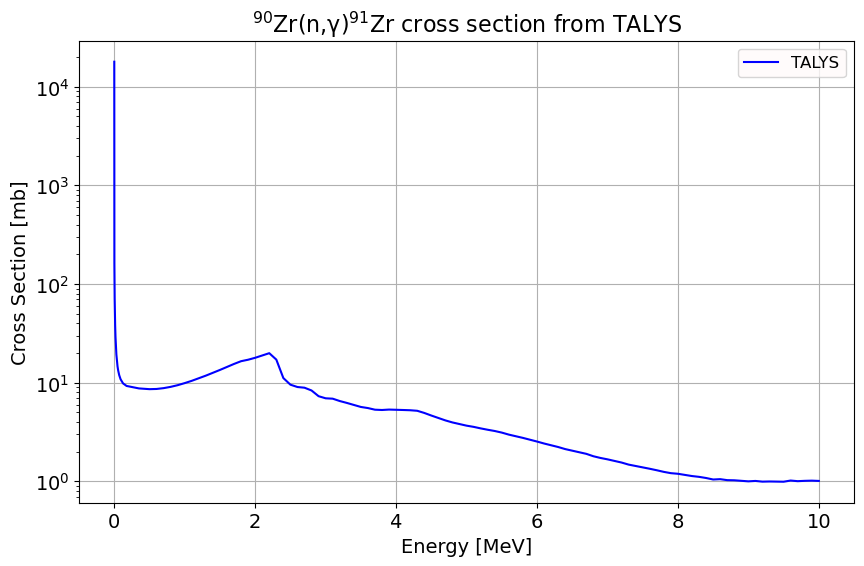

In [428]:
# Zr90_n_γ_data = np.loadtxt(Zr90_n_γ)

# Zr90_n_γ_E  = Zr90_n_γ_data[:, 0]
# Zr90_n_γ_CS = Zr90_n_γ_data[:, 1]


# plt.plot(Zr90_n_γ_E, Zr90_n_γ_CS)

# # plt.semilogx()
# plt.semilogy()

# plt.xlabel('Energy [MeV]')
# plt.ylabel('Cross section [mb]')

# plt.title(r"$^{90}$Zr(n,γ)$^{91}$Zr cross section from TALYS")

Zr90_n_γ = cwd / 'Zr90/rp040091.tot'
plot_TALYS_data(Zr90_n_γ, title=r"$^{90}$Zr(n,γ)$^{91}$Zr cross section from TALYS", color='blue')

plt.savefig(fig_dir / 'Zr90_n_gamma_cross_section')
plt.show()

#### EXFOR Data Comparison
##### Request Parameters:
- Target: Zr-90
- Reaction: n,g
- Quantity: CS*

##### Dataset Qualifiers:
- MF = 3 (reaction cross sections)
- MT = 102 (γ)

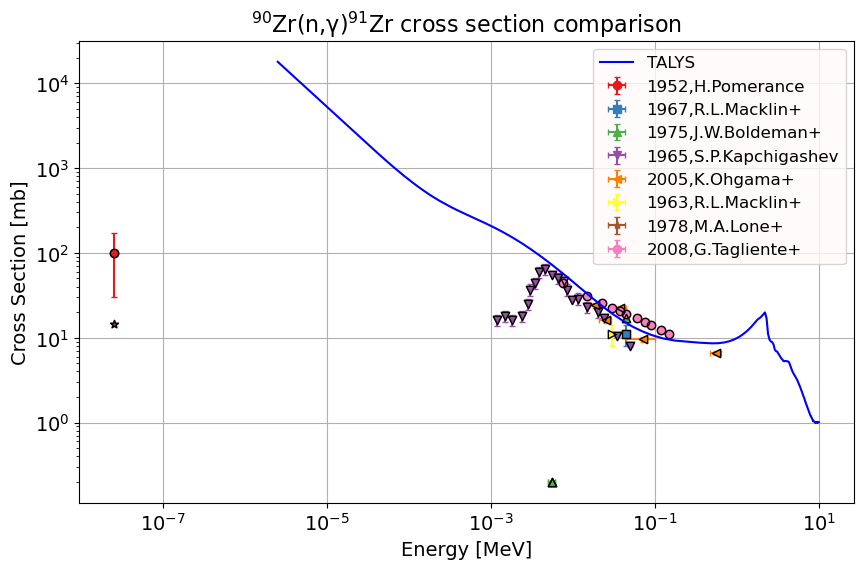

In [429]:
# plt.plot(Zr90_n_γ_E, Zr90_n_γ_CS, label='TALYS', color='black', linewidth=2)

# # plt.semilogx()
# plt.semilogy()

# plt.xlabel('Energy [MeV]')
# plt.ylabel('Cross section [mb]')
# plt.xlim(1e-3, 0.160)

# plt.legend()
# plt.title(r"$^{90}$Zr(n,γ)$^{91}$Zr cross section from various authors")

Zr90_exfor_data = read_exfor_data(cwd / 'Zr90/exfor_complete_data.json')
plot_exfor_data(Zr90_exfor_data)    
plot_TALYS_data(Zr90_n_γ, title=r"$^{90}$Zr(n,γ)$^{91}$Zr cross section comparison", color='blue', logx=True)

# plt.xlim(1e-3, 0.160)

plt.savefig(fig_dir / 'Zr90_n_gamma_cross_section_comparison_selected_data')
plt.show()

# Exercise 2

## $^{208}\text{Pb}$

### $(n, n')$

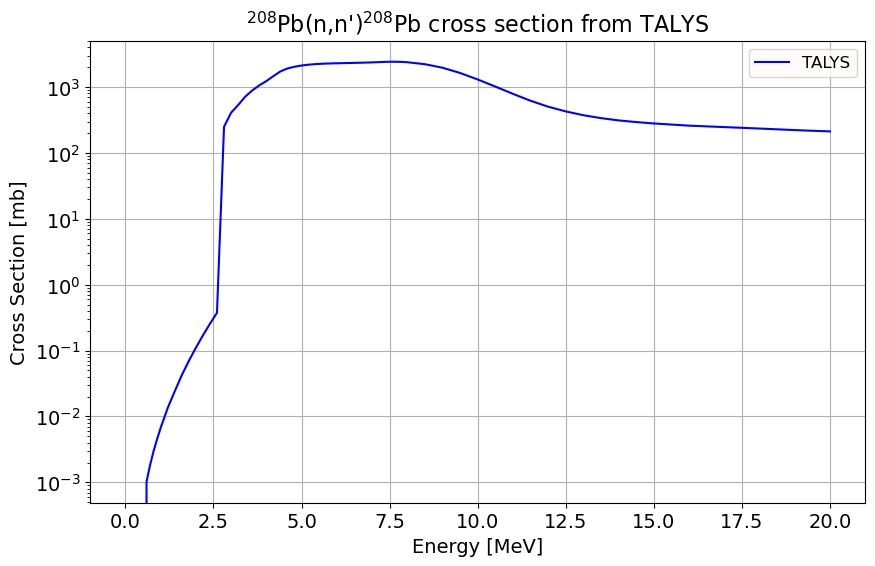

In [430]:
# Pb208_n_nprime_data = np.loadtxt(Pb208_n_nprime)

# Pb208_n_nprime_E  = Pb208_n_nprime_data[:, 0]
# Pb208_n_nprime_CS = Pb208_n_nprime_data[:, 1]

# plt.plot(Pb208_n_nprime_E, Pb208_n_nprime_CS)

# # plt.semilogx()
# plt.semilogy()

# plt.xlabel('Energy [MeV]')
# plt.ylabel('Cross section [mb]')

# plt.title(r"$^{208}$Pb(n,n')$^{208}$Pb cross sections from TALYS")

Pb208_n_nprime = cwd / 'Pb208/default/rp082208.tot'
plot_TALYS_data(Pb208_n_nprime, title=r"$^{208}$Pb(n,n')$^{208}$Pb cross section from TALYS", color='blue')

plt.savefig(fig_dir / 'Pb208_n_nprime_cross_section')
plt.show()


#### EXFOR Data Comparison
##### Request Parameters:
- Target: Pb-208
- Reaction: n,inl
- Quantity: CS*

##### Dataset Qualifiers:
- MF = 3 (reaction cross sections)
- MT = 4 (inelastic)

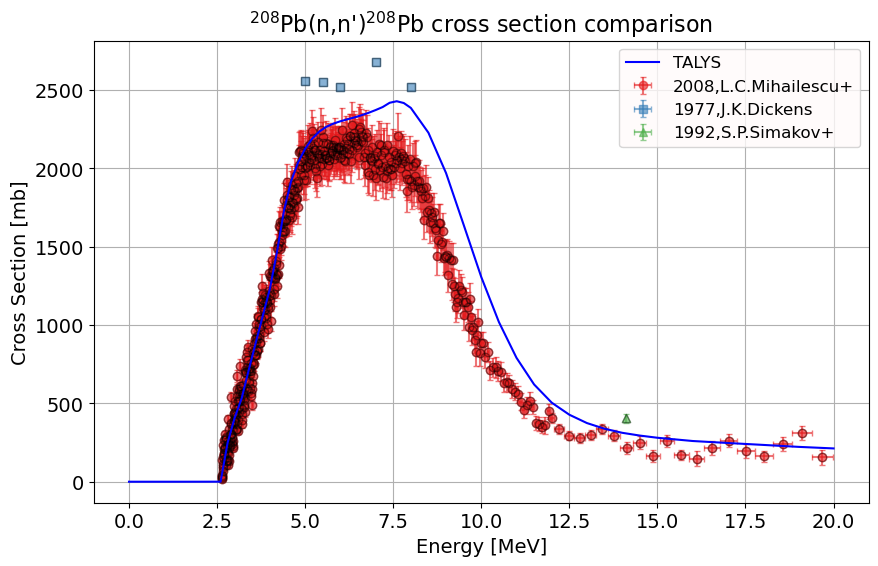

In [431]:


# plt.plot(Pb208_n_nprime_E, Pb208_n_nprime_CS, label='TALYS', color='lime', linewidth=2, zorder=3)

# # plt.semilogx()
# # plt.semilogy()

# plt.xlabel('Energy [MeV]')
# plt.ylabel('Cross section [mb]')
# # plt.xlim(0, 20)

# plt.legend()
# plt.title(r"$^{208}$Pb(n,n')$^{208}$Pb cross section from various authors")

Pb208_n_nprime_exfor_data = read_exfor_data(cwd / 'Pb208/exfor_n_nprime_complete_data.json')
plot_exfor_data(Pb208_n_nprime_exfor_data, face_alpha=0.6, border_alpha=0.4)
plot_TALYS_data(Pb208_n_nprime, title=r"$^{208}$Pb(n,n')$^{208}$Pb cross section comparison", color='blue', logy=False)

plt.savefig(fig_dir / 'Pb208_n_nprime_inl_cross_section_comparison_complete_data')
plt.show()

### $(n, 2n)$

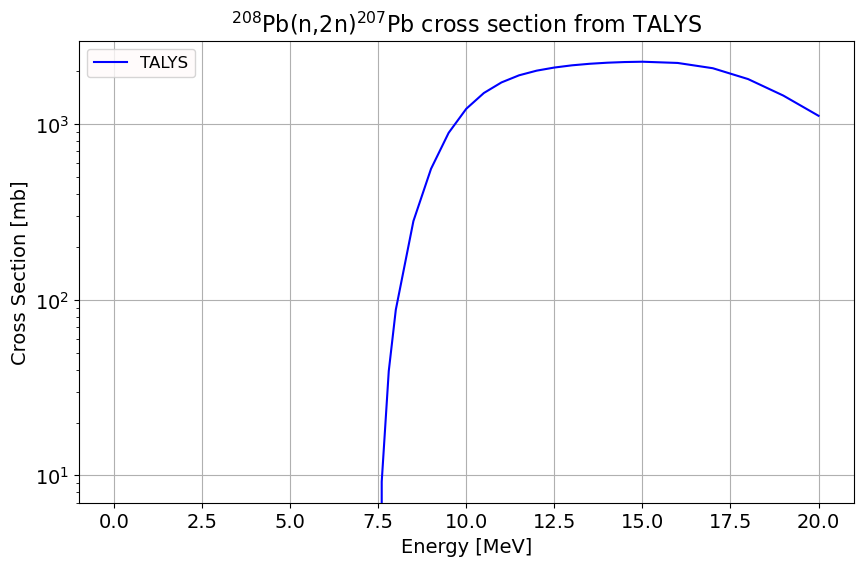

In [432]:
# Pb208_n_2n_data = np.loadtxt(Pb208_n_2n)

# Pb208_n_2n_E  = Pb208_n_2n_data[:, 0]
# Pb208_n_2n_CS = Pb208_n_2n_data[:, 1]

# plt.plot(Pb208_n_2n_E, Pb208_n_2n_CS)

# # plt.semilogx()
# plt.semilogy()

# plt.xlabel('Energy [MeV]')
# plt.ylabel('Cross section [mb]')

# plt.title(r"$^{208}$Pb(n,2n)$^{207}$Pb cross sections from TALYS")
Pb208_n_2n = cwd / 'Pb208/default/rp082207.tot'
plot_TALYS_data(Pb208_n_2n, title=r"$^{208}$Pb(n,2n)$^{207}$Pb cross section from TALYS", color='blue')

plt.savefig(fig_dir / 'Pb208_n_2n_cross_section')
plt.show()

#### EXFOR Data Comparison
##### Request Parameters:
- Target: Pb-208
- Reaction: n,2n
- Quantity: CS*

##### Dataset Qualifiers:
- MF = 3 (reaction cross sections)
- MT = 16 (2n)

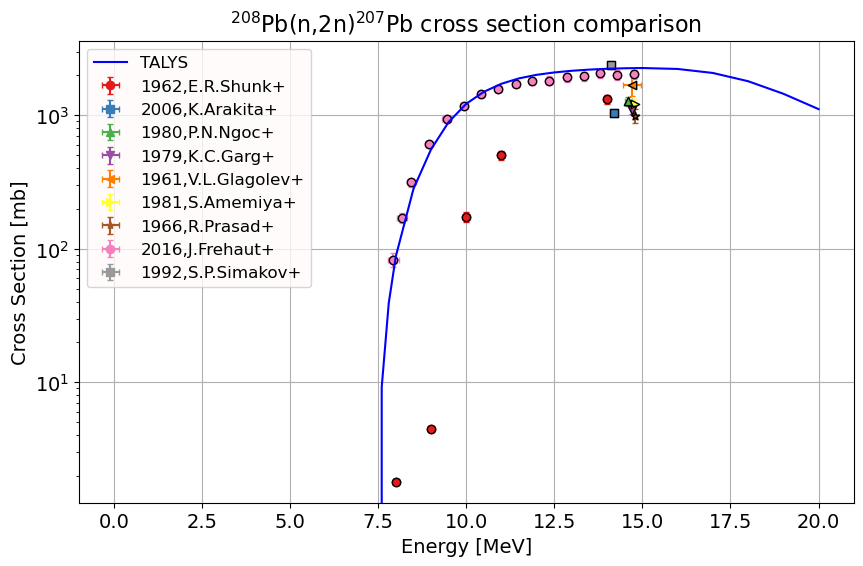

In [433]:
# plt.plot(Pb208_n_2n_E, Pb208_n_2n_CS, label='TALYS', color='black', linewidth=2, zorder=3)

# # plt.semilogx()
# plt.semilogy()

# plt.xlabel('Energy [MeV]')
# plt.ylabel('Cross section [mb]')
# plt.xlim(0, 20)

# plt.legend()
# plt.title(r"$^{208}$Pb(n,2n)$^{207}$Pb cross section from various authors")
Pb208_n_2n_exfor_data = read_exfor_data(cwd / 'Pb208/exfor_n_2n_complete_data.json')
plot_exfor_data(Pb208_n_2n_exfor_data)
plot_TALYS_data(Pb208_n_2n, title=r"$^{208}$Pb(n,2n)$^{207}$Pb cross section comparison", color='blue')

plt.savefig(fig_dir / 'Pb208_n_2n_cross_section_comparison_complete_data')
plt.show()

### $(n, γ)$

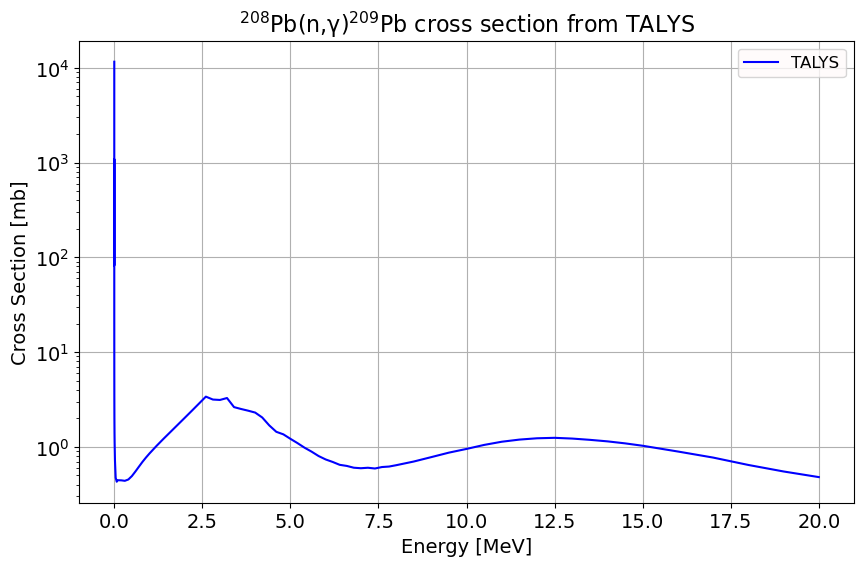

In [434]:
# Pb208_n_γ_data = np.loadtxt(Pb208_n_γ)

# Pb208_n_γ_E  = Pb208_n_γ_data[:, 0]
# Pb208_n_γ_CS = Pb208_n_γ_data[:, 1]

# plt.plot(Pb208_n_γ_E, Pb208_n_γ_CS)

# # plt.semilogx()
# plt.semilogy()

# plt.xlabel('Energy [MeV]')
# plt.ylabel('Cross section [mb]')

# plt.title(r"$^{208}$Pb(n,γ)$^{209}$Pb cross sections from TALYS")
Pb208_n_γ = cwd / 'Pb208/default/rp082209.tot'
plot_TALYS_data(Pb208_n_γ, title=r"$^{208}$Pb(n,γ)$^{209}$Pb cross section from TALYS", color='blue')


plt.savefig(fig_dir / 'Pb208_n_gamma_cross_section')
plt.show() 

#### EXFOR Data Comparison
##### Request Parameters:
- Target: Pb-208
- Reaction: n,g
- Quantity: CS*

##### Dataset Qualifiers:
- MF = 3 (reaction cross sections)
- MT = 102 (γ)

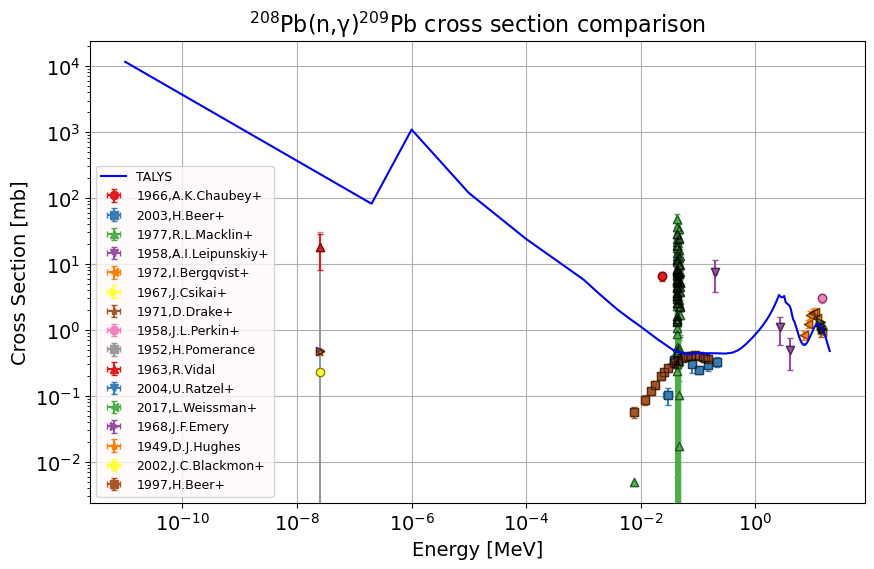

In [435]:
# plt.plot(Pb208_n_γ_E, Pb208_n_γ_CS, label='TALYS', color='black', linewidth=2, zorder=3)

# plt.semilogx()
# plt.semilogy()

# plt.xlabel('Energy [MeV]')
# plt.ylabel('Cross section [mb]')    
# # plt.xlim(0, 20)

# plt.legend(fontsize=10)
# plt.title(r"$^{208}$Pb(n,γ)$^{209}$Pb cross section from various authors")

Pb208_n_γ_exfor_data = read_exfor_data(cwd / 'Pb208/exfor_n_g_complete_data.json')
plot_exfor_data(Pb208_n_γ_exfor_data, border_alpha=0.5)
plot_TALYS_data(Pb208_n_γ, title=r"$^{208}$Pb(n,γ)$^{209}$Pb cross section comparison", color='blue', logx=True)

plt.legend(fontsize=9)

plt.savefig(fig_dir / 'Pb208_n_gamma_cross_section_comparison_complete_data')
plt.show()

# EXercise 3

## $^{208}\text{Pb}(\text{n}, \gamma)$ Varying Models
### γ-ray strength function models: 
- strength 1: Kopecky-Uhl generalized Lorentzian
- strength 2: Brink-Axel Lorentzian
- strength 3: Hartree-Fock BCS tables
- strength 4: Hartree-Fock-Bogoliubov tables
- strength 5: Goriely’s hybrid model [48]
- strength 6: Goriely T-dependent HFB
- strength 7: T-dependent RMF
- strength 8: Gogny D1M HFB+QRPA
- strength 9: SMLO

### Level density models:
- ldmodel 1: Constant Temperature + Fermi gas model (CTM)
- ldmodel 2: Back-shifted Fermi gas Model (BFM)
- ldmodel 3: Generalised Superfluid Model (GSM)
- ldmodel 4: Skyrme-Hartree-Fock-Bogoluybov level densities from numerical tables
- ldmodel 5: Gogny-Hartree-Fock-Bogoluybov level densities from numerical tables
- ldmodel 6: Temperature-dependent Gogny-Hartree-Fock-Bogoluybov level densities from
- numerical tables

In [436]:
Pb208_n_γ_varying_models = [[cwd / f'Pb208/d{d}s{s}/rp082209.tot' for s in range(1,10)] for d in range(1,7)]

Pb208_n_γ_varying_models_data = {d: {s: {'E': np.loadtxt(file)[:,0], 'CS': np.loadtxt(file)[:,1]} for s, file in enumerate(row, start=1)} for d, row in enumerate(Pb208_n_γ_varying_models, start=1)}


Pb208_n_γ_best = cwd / 'Pb208' / 'best' / 'rp082209.tot'
Pb208_n_γ_best_data = np.loadtxt(Pb208_n_γ_best)

Pb208_n_γ_best_E  = Pb208_n_γ_best_data[:, 0]
Pb208_n_γ_best_CS = Pb208_n_γ_best_data[:, 1]

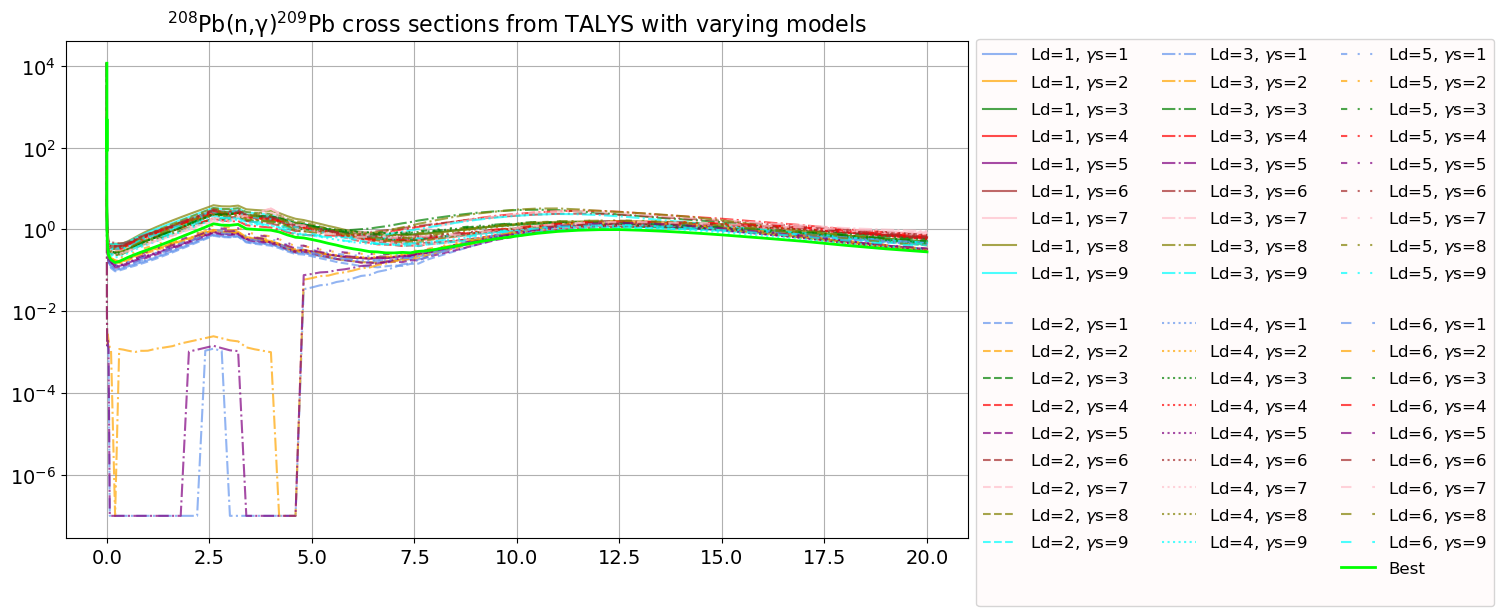

In [437]:
linestyles = cycle(['-', '--', '-.', ':', (0, (3, 5, 1, 5, 1, 5)), (0, (5, 10))])
colors = cycle(['cornflowerblue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'olive', 'cyan'])

for d, row in enumerate(Pb208_n_γ_varying_models_data, start=1):
    linestyle = next(linestyles)
    for s in Pb208_n_γ_varying_models_data[d]:
        E  = Pb208_n_γ_varying_models_data[d][s]['E']
        CS = Pb208_n_γ_varying_models_data[d][s]['CS']
        plt.plot(E, CS, label=f'Ld={d}, $γ$s={s}', linestyle=linestyle, alpha=0.7, color=next(colors))
        
        if (d == 2 and s == 9) or (d == 4 and s == 9):
            plt.plot([], [], ' ', label=' ')  # Ghost plot for better legend spacing
            
    if d != 6:
        plt.plot([], [], ' ', label=' ')  # Ghost plot for better legend spacing between level density models


plt.plot(Pb208_n_γ_best_E, Pb208_n_γ_best_CS, label='Best', color='lime', linewidth=2, zorder=3)
# plt.semilogx()
plt.semilogy()

plt.title(r"$^{208}$Pb(n,γ)$^{209}$Pb cross sections from TALYS with varying models")
plt.tight_layout()
plt.legend(fontsize=12, ncols=3, bbox_to_anchor=(1,1.02))

plt.savefig(fig_dir / 'Pb208_n_gamma_cross_section_varying_models', bbox_inches='tight')
plt.show()

## EXFOR Data Comparison
### Request Parameters:
- Target: Pb-208
- Reaction: n,g
- Quantity: CS*

### Dataset Qualifiers:
- MF = 3 (reaction cross sections)
- MT = 102 (γ)

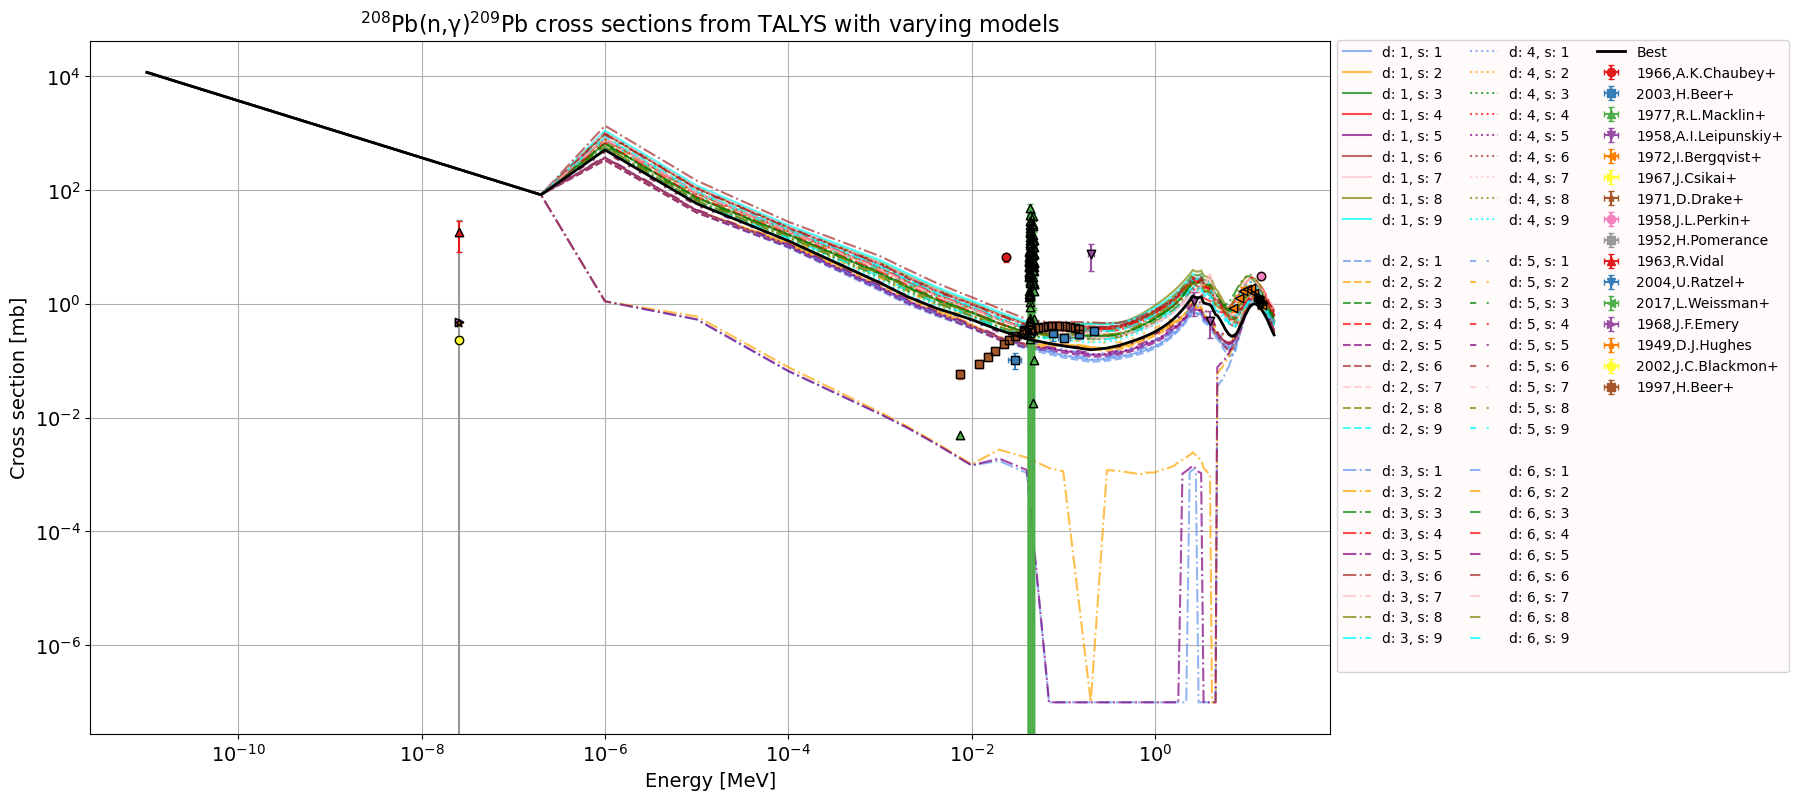

In [438]:
plt.figure(figsize=(16,9))
for d, level_density_row in enumerate(Pb208_n_γ_varying_models_data, start=1):
    linestyle = next(linestyles)
    for s in Pb208_n_γ_varying_models_data[d]:
        E = Pb208_n_γ_varying_models_data[d][s]['E']
        CS = Pb208_n_γ_varying_models_data[d][s]['CS']
        plt.plot(E, CS, label=f'd: {d}, s: {s}', alpha=0.7, linestyle=linestyle, color=next(colors))
        
    # if d == 3:
    #     continue
    
    plt.plot([], [], ' ', label=' ')  # Ghost plot for better legend spacing between gamma strength function models

plt.plot(Pb208_n_γ_best_E, Pb208_n_γ_best_CS, label='Best', color='black', linewidth=2, zorder=3)

plot_exfor_data(Pb208_n_γ_exfor_data)     

# Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Add 13 spacers to the END
for _ in range(13):
    handles.append(plt.Line2D([], [], linestyle='None'))
    labels.append(' ')   



plt.semilogx()
plt.semilogy()

plt.xlabel('Energy [MeV]')
plt.ylabel('Cross section [mb]')
plt.title(r"$^{208}$Pb(n,γ)$^{209}$Pb cross sections from TALYS with varying models")


plt.legend(fontsize=10, ncols=3, bbox_to_anchor=(1,1.0115), handles=handles, labels=labels)
plt.savefig(fig_dir / 'Pb208_n_gamma_cross_section_varying_models_with_exfor', bbox_inches='tight')
plt.show()

#### Finding the Optimal Model

##### Test Interpolation

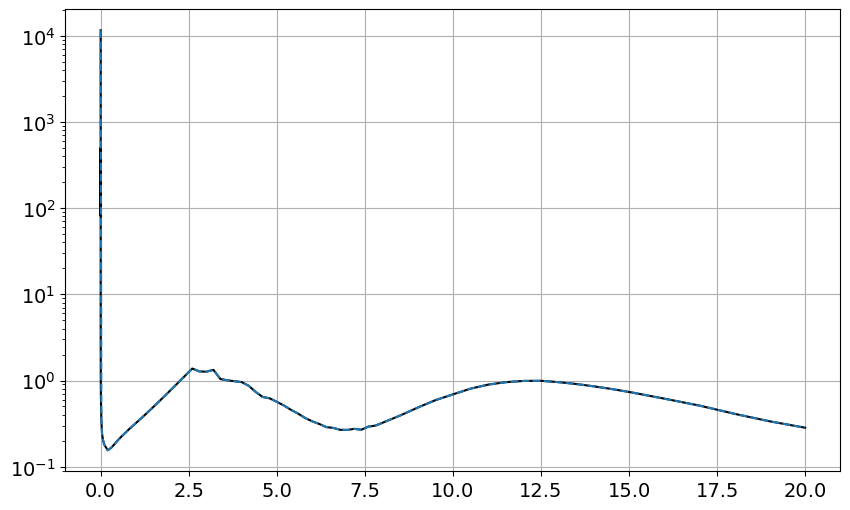

In [439]:
plt.plot(Pb208_n_γ_best_E, Pb208_n_γ_best_CS, label='Best', color='black')

log_CS = np.log10(Pb208_n_γ_best_CS)
log_interp = interp1d(Pb208_n_γ_best_E, log_CS)

E_interpolated  = np.linspace(Pb208_n_γ_best_E.min(), Pb208_n_γ_best_E.max(), 1000)
CS_interpolated = 10**log_interp(E_interpolated)

plt.plot(E_interpolated, CS_interpolated, '--', label='Interpolated')
plt.semilogy()
# plt.semilogx()
plt.show()

##### Fitting All Models

In [440]:
# Combine data from all EXFOR authors
E_exfor_all = np.array([])
CS_exfor_all = np.array([])
for author in Pb208_n_γ_exfor_data:
    if author == '1977,R.L.Macklin+':
        continue
    E_exfor  = Pb208_n_γ_exfor_data[author]['x']
    CS_exfor = Pb208_n_γ_exfor_data[author]['y']
    
    E_exfor_all  = np.concatenate((E_exfor_all, E_exfor))
    CS_exfor_all = np.concatenate((CS_exfor_all, CS_exfor))

In [441]:
mse_rankings = []
for d in Pb208_n_γ_varying_models_data:
    for s in Pb208_n_γ_varying_models_data[d]:
        E  = Pb208_n_γ_varying_models_data[d][s]['E']
        CS = Pb208_n_γ_varying_models_data[d][s]['CS']
        
        
        # Creating a log fit to be able to evaluate all EXFOR data points
        log_CS = np.log10(CS)
        log_interp = interp1d(E, log_CS, fill_value="extrapolate") # type: ignore
        
        CS_model_at_exfor_energies = 10**log_interp(E_exfor_all)
        
        # Filter out invalid values (zeros, negatives, NaNs)
        valid_mask = (CS_model_at_exfor_energies > 0) & (CS_exfor_all > 0) & \
                     np.isfinite(CS_model_at_exfor_energies) & np.isfinite(CS_exfor_all)
        
        CS_model_valid = CS_model_at_exfor_energies[valid_mask]
        CS_exfor_valid = CS_exfor_all[valid_mask]
        
        if len(CS_model_valid) == 0:
            continue  # Skip if no valid points
        
        # 1. Mean Squared Log Error (MSLE) - penalizes relative errors in log space
        msle = np.mean((np.log10(CS_model_valid) - np.log10(CS_exfor_valid))**2)
        
        # 2. Mean Relative Error (MRE) - average relative deviation
        mre = np.mean((CS_model_valid - CS_exfor_valid) / CS_exfor_valid)
        
        # 3. Mean Absolute Relative Error (MARE) - average magnitude of relative error
        mare = np.mean(np.abs((CS_model_valid - CS_exfor_valid) / CS_exfor_valid))
        
        # 4. Root Mean Squared Log Error (RMSLE)
        rmsle = np.sqrt(msle)
        
        mse_rankings.append({'d': d, 's': s, 'msle': msle, 'mre': mre, 'mare': mare, 'rmsle': rmsle})

# Calculating MSE for talys "best" model
# Creating a log fit to be able to evaluate all EXFOR data points
log_CS = np.log10(Pb208_n_γ_best_CS)
log_interp = interp1d(Pb208_n_γ_best_E, log_CS, fill_value="extrapolate") # type: ignore

CS_model_at_exfor_energies = 10**log_interp(E_exfor_all)
# Filter out invalid values (zeros, negatives, NaNs)
valid_mask = (CS_model_at_exfor_energies > 0) & (CS_exfor_all > 0) & \
             np.isfinite(CS_model_at_exfor_energies) & np.isfinite(CS_exfor_all)
             
CS_model_valid = CS_model_at_exfor_energies[valid_mask]
CS_exfor_valid = CS_exfor_all[valid_mask]

talys_best_model_mse = {}
if len(CS_model_valid) != 0:
    # 1. Mean Squared Log Error (MSLE) - penalizes relative errors in log space
    msle = np.mean((np.log10(CS_model_valid) - np.log10(CS_exfor_valid))**2)
    
    # 2. Mean Relative Error (MRE) - average relative deviation
    mre = np.mean((CS_model_valid - CS_exfor_valid) / CS_exfor_valid)
    
    # 3. Mean Absolute Relative Error (MARE) - average magnitude of relative error
    mare = np.mean(np.abs((CS_model_valid - CS_exfor_valid) / CS_exfor_valid))
    
    # 4. Root Mean Squared Log Error (RMSLE)
    rmsle = np.sqrt(msle)
    
    talys_best_model_mse = {'msle': msle, 'mre': mre, 'mare': mare, 'rmsle': rmsle}
    


# Sort by MSLE (best for log-scale) or MARE (most interpretable)
mse_rankings = sorted(mse_rankings, key=lambda x: x['msle'])
talys_best_model_rank = 1 + sum(1 for result in mse_rankings if result['msle'] < talys_best_model_mse['msle'])

print(f"TALYS 'best' model rank: {talys_best_model_rank}")
print(f'MSLE: {talys_best_model_mse["msle"]:.3e}, MRE: {talys_best_model_mse["mre"]:.3e}, MARE: {talys_best_model_mse["mare"]:.3e}, RMSLE: {talys_best_model_mse["rmsle"]:.3e}\n')



table = []
for rank, result in enumerate(mse_rankings, start=1):
    table.append([rank, result['d'], result['s'], f"{result['msle']:.3e}", f"{result['mre']:.3e}", f"{result['mare']:.3e}", f"{result['rmsle']:.3e}"])
    
headers = ["Rank", "Ld", "γs", "MSLE", "MRE", "MARE", "RMSLE"]
print(tabulate.tabulate(table, headers=headers, tablefmt="grid", disable_numparse=True))

TALYS 'best' model rank: 42
MSLE: 6.505e-01, MRE: 3.748e+01, MARE: 3.811e+01, RMSLE: 8.066e-01

+--------+------+------+-----------+-----------+-----------+-----------+
| Rank   | Ld   | γs   | MSLE      | MRE       | MARE      | RMSLE     |
+========+======+======+===========+===========+===========+===========+
| 1      | 4    | 8    | 6.104e-01 | 3.777e+01 | 3.810e+01 | 7.813e-01 |
+--------+------+------+-----------+-----------+-----------+-----------+
| 2      | 6    | 8    | 6.107e-01 | 3.794e+01 | 3.820e+01 | 7.815e-01 |
+--------+------+------+-----------+-----------+-----------+-----------+
| 3      | 5    | 3    | 6.109e-01 | 3.793e+01 | 3.817e+01 | 7.816e-01 |
+--------+------+------+-----------+-----------+-----------+-----------+
| 4      | 4    | 3    | 6.120e-01 | 3.792e+01 | 3.818e+01 | 7.823e-01 |
+--------+------+------+-----------+-----------+-----------+-----------+
| 5      | 6    | 3    | 6.121e-01 | 3.795e+01 | 3.819e+01 | 7.824e-01 |
+--------+------+------+----

#### Plotting Best Model

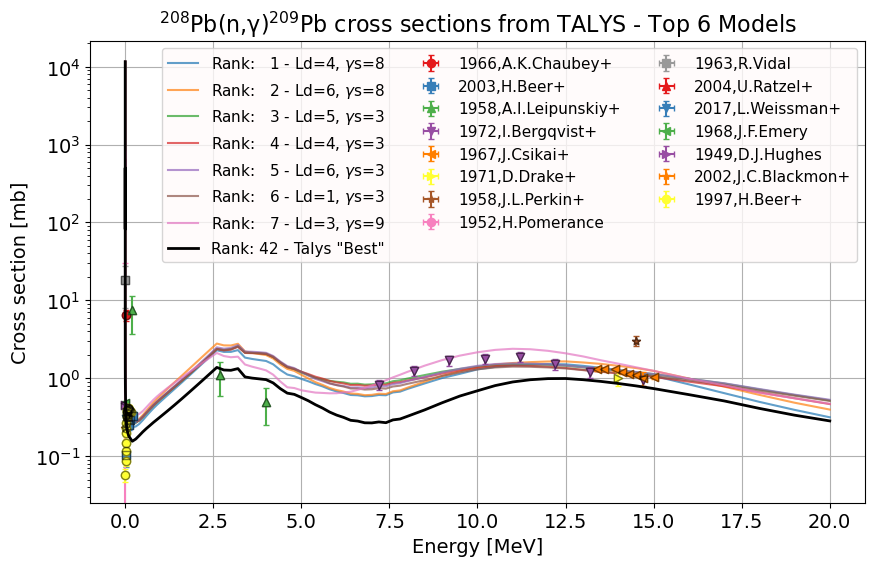

In [442]:
n = 6
for rank, model in enumerate(mse_rankings[: n+1], start=1):
    d = model['d']
    s = model['s']
    E = Pb208_n_γ_varying_models_data[d][s]['E']
    CS = Pb208_n_γ_varying_models_data[d][s]['CS']
    plt.plot(E, CS, label=f'Rank:{rank:>4} - Ld={d}, $γ$s={s}', alpha=0.7)

    
plt.plot(Pb208_n_γ_best_E, Pb208_n_γ_best_CS, label=f'Rank: {talys_best_model_rank} - Talys "Best"', color='black', linewidth=2, zorder=3)

Pb208_n_γ_exfor_data_no_macklin = {author: Pb208_n_γ_exfor_data[author] for author in Pb208_n_γ_exfor_data if author != '1977,R.L.Macklin+'}
plot_exfor_data(Pb208_n_γ_exfor_data_no_macklin, border_alpha=0.5)

# plt.semilogx()
plt.semilogy()
# plt.xlim(1.1, 20)
# plt.ylim(1e-1, 1e1)

plt.xlabel('Energy [MeV]')
plt.ylabel('Cross section [mb]')

plt.title(f"{r"$^{208}$Pb(n,γ)$^{209}$Pb"} cross sections from TALYS - Top {n} Models")
plt.legend(ncols=3, fontsize=11)

plt.savefig(f'Pb208_n_gamma_cross_section_top_{n}_models_with_exfor')
plt.show()

# Exercise 4

## $^{191}\text{Os}(n,γ)$

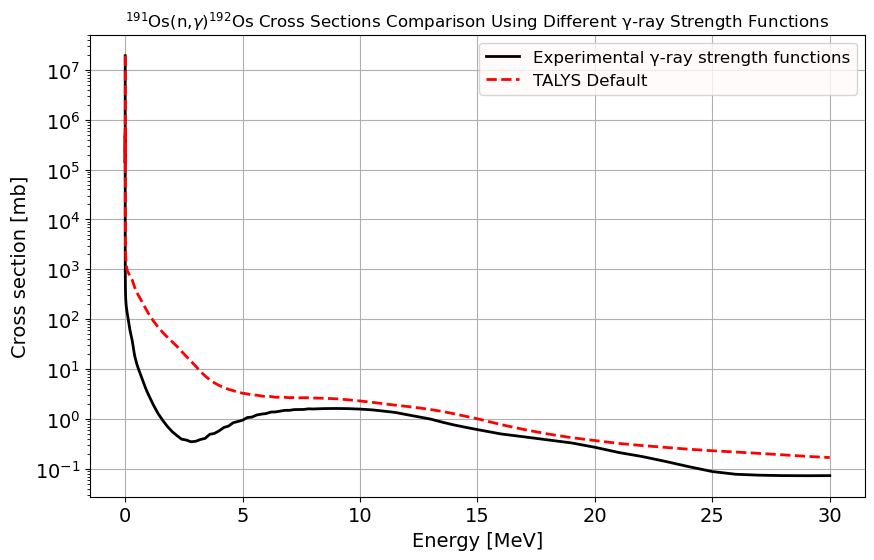

In [443]:
Os191_n_γ_experimental = cwd / 'Os191/exp/rp076192.tot'
Os191_n_γ_experimental_data = np.loadtxt(Os191_n_γ_experimental)

Os191_n_γ_experimental_E  = Os191_n_γ_experimental_data[:, 0]
Os191_n_γ_experimental_CS = Os191_n_γ_experimental_data[:, 1]

Os191_n_γ_data = np.loadtxt(Os191_n_γ)

Os191_n_γ_E  = Os191_n_γ_data[:, 0]
Os191_n_γ_CS = Os191_n_γ_data[:, 1]

plt.plot(Os191_n_γ_experimental_E, Os191_n_γ_experimental_CS, label='Experimental γ-ray strength functions', color='black', linewidth=2)
plt.plot(Os191_n_γ_E, Os191_n_γ_CS, label='TALYS Default', color='red', linestyle='--', linewidth=2)

# plt.semilogx()
plt.semilogy()

plt.xlabel('Energy [MeV]')
plt.ylabel('Cross section [mb]')

plt.title(r"$^{191}$Os(n,$γ$)$^{192}$Os Cross Sections Comparison Using Different γ-ray Strength Functions", fontsize=12)

plt.legend()

plt.savefig(fig_dir / 'Os191_n_gamma_cross_section_experimental_data')
plt.show()

# Task

## $^{120}\text{Sn}$(n,γ) 

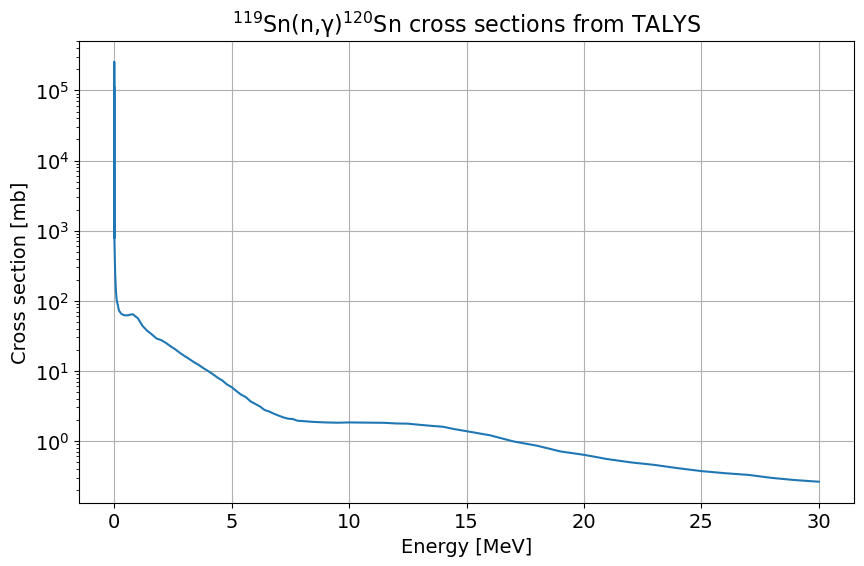

In [ ]:
Sn120_n_γ = cwd / 'Sn119/default/rp050120.tot'
Sn119_n_γ_data = np.loadtxt(Sn120_n_γ)

Sn119_n_γ_E  = Sn119_n_γ_data[:, 0]
Sn119_n_γ_CS = Sn119_n_γ_data[:, 1]

plt.plot(Sn119_n_γ_E, Sn119_n_γ_CS)

# plt.semilogx()
plt.semilogy()

# plt.xlim(0, 1)

plt.xlabel('Energy [MeV]')
plt.ylabel('Cross section [mb]')


plt.title(r"$^{119}$Sn(n,γ)$^{120}$Sn cross sections from TALYS")

plt.savefig(fig_dir / 'Sn119_n_gamma_cross_section')
plt.show()

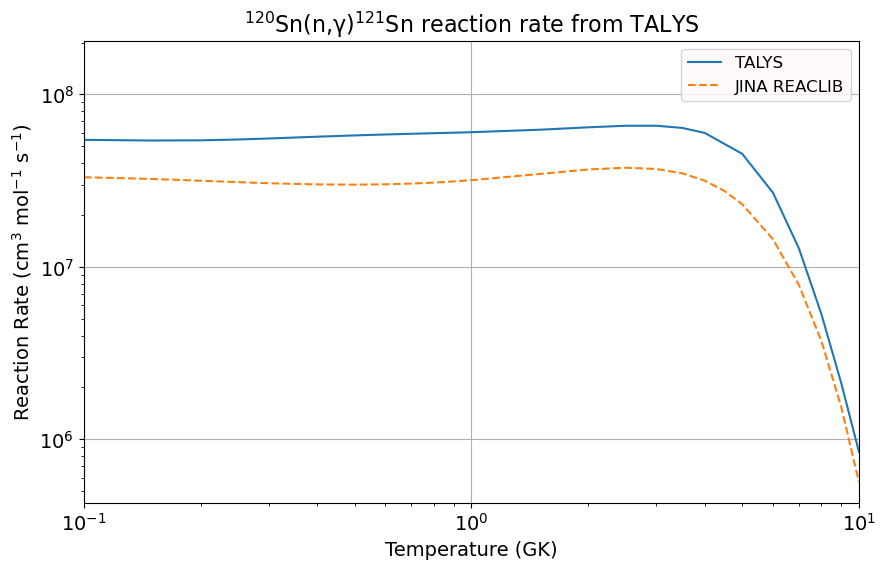

In [ ]:
Sn119_n_γ_rr = cwd / 'Sn119/default/astrorate.g'
Sn119_n_γ_rr_data = np.loadtxt(Sn119_n_γ_rr)

Sn119_n_γ_rr_jina = cwd / 'Sn119_reaction_rates.txt'
Sn119_n_γ_rr_jina_data = np.loadtxt(Sn119_n_γ_rr_jina)

Sn119_n_γ_rr_T  = Sn119_n_γ_rr_data[:, 0]
Sn119_n_γ_rr_RR = Sn119_n_γ_rr_data[:, 1]


Sn119_n_γ_rr_jina_T  = Sn119_n_γ_rr_jina_data[:, 0]
Sn119_n_γ_rr_jina_RR = Sn119_n_γ_rr_jina_data[:, 1]


plt.plot(Sn119_n_γ_rr_T, Sn119_n_γ_rr_RR, label='TALYS')
plt.plot(Sn119_n_γ_rr_jina_T, Sn119_n_γ_rr_jina_RR, label='JINA REACLIB', linestyle='--')

plt.semilogx()
plt.semilogy()

plt.xlim(1e-1, 1e1)

plt.xlabel('Temperature (GK)')
plt.ylabel('Reaction Rate (cm$^3$ mol$^{-1}$ s$^{-1}$)')

plt.title(r"$^{119}$Sn(n,γ)$^{120}$Sn reaction rate from TALYS")
plt.legend()

plt.show()

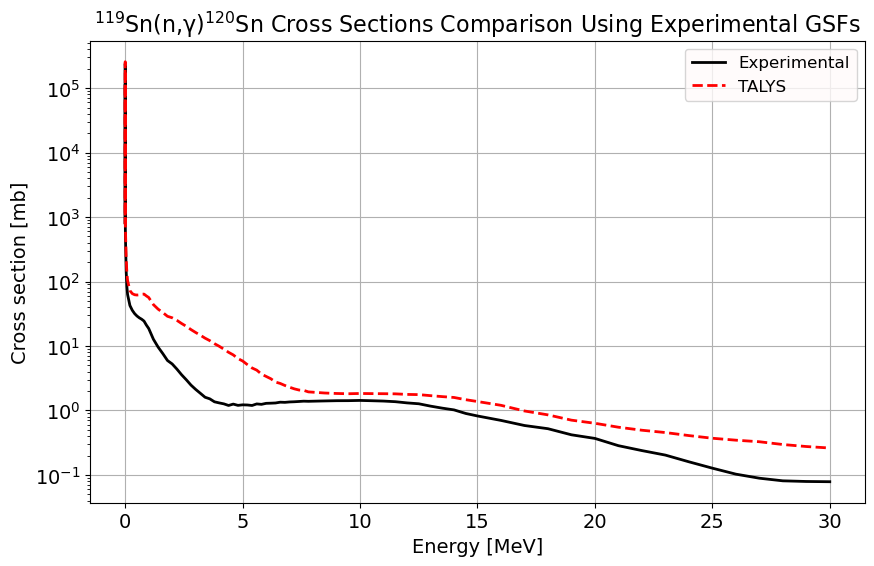

In [446]:
Sn119_n_γ_exp = cwd / 'Sn119/exp/rp050120.tot'
Sn119_n_γ_exp_data = np.loadtxt(Sn119_n_γ_exp)

Sn119_n_γ_exp_E  = Sn119_n_γ_exp_data[:, 0]
Sn119_n_γ_exp_CS = Sn119_n_γ_exp_data[:, 1]

plt.plot(Sn119_n_γ_exp_E, Sn119_n_γ_exp_CS, label='Experimental', color='black', linewidth=2)
plt.plot(Sn119_n_γ_E, Sn119_n_γ_CS, label='TALYS', color='red', linestyle='--', linewidth=2)    

# plt.semilogx()
plt.semilogy()

plt.xlabel('Energy [MeV]')
plt.ylabel('Cross section [mb]')

plt.title(r"$^{119}$Sn(n,γ)$^{120}$Sn Cross Sections Comparison Using Experimental GSFs")
plt.legend()

plt.savefig(fig_dir / 'Sn119_n_gamma_cross_section_experimental_data')
plt.show()

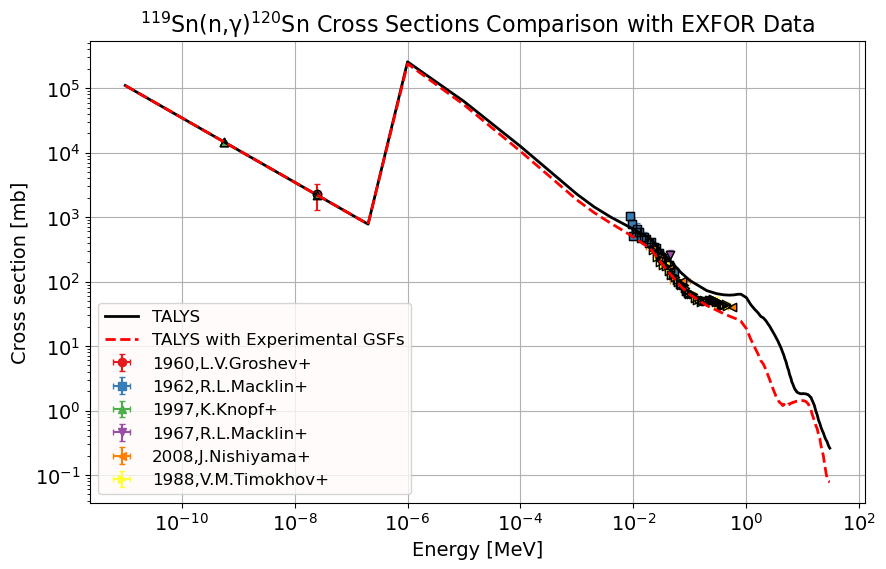

In [447]:
Sn119_n_γ_exfor = cwd / 'Sn119/exfor_complete_data.json'
Sn119_n_γ_exfor_data = read_exfor_data(Sn119_n_γ_exfor)

plot_exfor_data(Sn119_n_γ_exfor_data)

plt.plot(Sn119_n_γ_E, Sn119_n_γ_CS, label='TALYS', color='black', linewidth=2, zorder=3)
plt.plot(Sn119_n_γ_exp_E, Sn119_n_γ_exp_CS, label='TALYS with Experimental GSFs', color='red', linestyle='--', linewidth=2, zorder=4)

plt.semilogx()
plt.semilogy()
# plt.xlim(1e-3, 1)

plt.xlabel('Energy [MeV]')
plt.ylabel('Cross section [mb]')

plt.title(r"$^{119}$Sn(n,γ)$^{120}$Sn Cross Sections Comparison with EXFOR Data")
plt.legend()

plt.savefig(fig_dir / 'Sn119_n_gamma_cross_section_exfor_comparison')
plt.show()

### Varying Models
#### γ-ray strength function models: 
- strength 1: Kopecky-Uhl generalized Lorentzian
- strength 2: Brink-Axel Lorentzian
- strength 3: Hartree-Fock BCS tables
- strength 4: Hartree-Fock-Bogoliubov tables
- strength 5: Goriely’s hybrid model [48]
- strength 6: Goriely T-dependent HFB
- strength 7: T-dependent RMF
- strength 8: Gogny D1M HFB+QRPA
- strength 9: SMLO

#### Level density models:
- ldmodel 1: Constant Temperature + Fermi gas model (CTM)
- ldmodel 2: Back-shifted Fermi gas Model (BFM)
- ldmodel 3: Generalised Superfluid Model (GSM)
- ldmodel 4: Skyrme-Hartree-Fock-Bogoluybov level densities from numerical tables
- ldmodel 5: Gogny-Hartree-Fock-Bogoluybov level densities from numerical tables
- ldmodel 6: Temperature-dependent Gogny-Hartree-Fock-Bogoluybov level densities from
- numerical tables

In [448]:
Sn120_n_γ_varying_models = [[cwd / 'Sn119' / f'd{d}s{s}' / 'rp050120.tot' for s in range(1,10)] for d in range(1,7)]

Sn120_n_γ_varying_models_data = {d: {s: {'E': np.loadtxt(file)[:,0], 'CS': np.loadtxt(file)[:,1]} for s, file in enumerate(row, start=1)} for d, row in enumerate(Sn120_n_γ_varying_models, start=1)}

Sn120_n_γ_best = cwd / 'Sn119' / 'best' / 'rp050120.tot'
Sn120_n_γ_best_data = np.loadtxt(Sn120_n_γ_best)

Sn120_n_γ_best_E  = Sn120_n_γ_best_data[:, 0]
Sn120_n_γ_best_CS = Sn120_n_γ_best_data[:, 1]

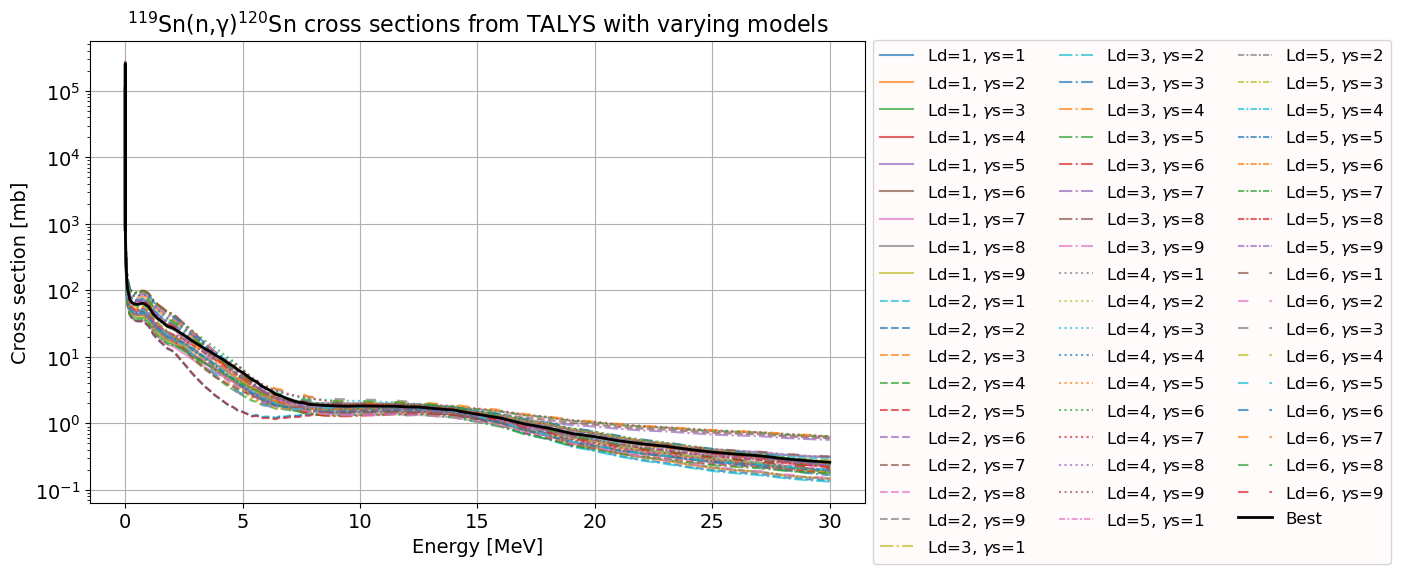

In [449]:
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 10))]
for d, row in enumerate(Sn120_n_γ_varying_models_data, start=1):
    for s in Sn120_n_γ_varying_models_data[d]:
        E  = Sn120_n_γ_varying_models_data[d][s]['E']
        CS = Sn120_n_γ_varying_models_data[d][s]['CS']
        plt.plot(E, CS, label=f'Ld={d}, $γ$s={s}', linestyle=linestyles[d-1], alpha=0.7)


plt.plot(Sn119_n_γ_E, Sn119_n_γ_CS, label='Best', color='black', linewidth=2, zorder=3)

# plt.semilogx()
plt.semilogy()

plt.xlabel('Energy [MeV]')
plt.ylabel('Cross section [mb]')

plt.title(r"$^{119}$Sn(n,γ)$^{120}$Sn cross sections from TALYS with varying models")
plt.legend(fontsize=12, ncols=3, bbox_to_anchor=(1,1.02))

plt.savefig(fig_dir / 'Sn119_n_gamma_cross_section_varying_models')
plt.show()

## EXFOR Data Comparison
### Request Parameters:
- Target: Sn-119
- Reaction: n,g
- Quantity: CS*

### Dataset Qualifiers:
- MF = 3 (reaction cross sections)
- MT = 102 (γ)

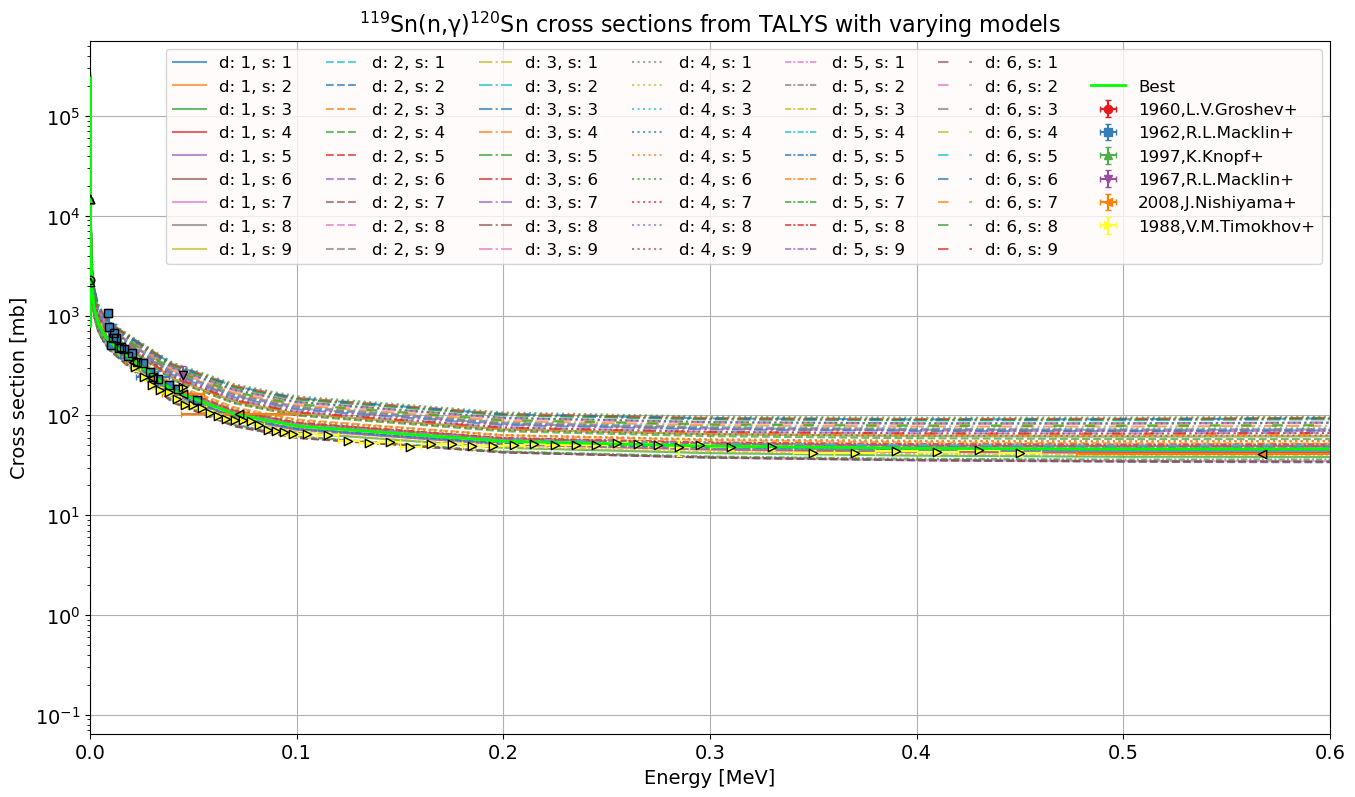

In [450]:
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 10))]

plt.figure(figsize=(16,9))
for d, level_density_row in enumerate(Sn120_n_γ_varying_models_data, start=1):
    for s in Sn120_n_γ_varying_models_data[d]:
        E = Sn120_n_γ_varying_models_data[d][s]['E']
        CS = Sn120_n_γ_varying_models_data[d][s]['CS']
        plt.plot(E, CS, label=f'd: {d}, s: {s}', alpha=0.7, linestyle=linestyles[d-1 % len(linestyles)])
    
    if d == 6:
        plt.plot([], [], ' ', label=' ')  # Ghost plot for better legend spacing between level density models
           
plt.plot(Sn120_n_γ_best_E, Sn120_n_γ_best_CS, label='Best', color='lime', linewidth=2, zorder=3)
plot_exfor_data(Sn119_n_γ_exfor_data)

# Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()



# plt.semilogx()
plt.semilogy()
plt.xlim(0, .6)

plt.xlabel('Energy [MeV]')
plt.ylabel('Cross section [mb]')
plt.title(r"$^{119}$Sn(n,γ)$^{120}$Sn cross sections from TALYS with varying models")
plt.legend(ncols=7)

plt.savefig(fig_dir / 'Sn119_n_gamma_cross_section_varying_models_with_exfor')
plt.show()

#### Finding the Optimal Model

In [451]:
# Combine data from all EXFOR authors
E_exfor_all = np.array([])
CS_exfor_all = np.array([])
for author in Sn119_n_γ_exfor_data:
    E_exfor  = Sn119_n_γ_exfor_data[author]['x']
    CS_exfor = Sn119_n_γ_exfor_data[author]['y']
    
    E_exfor_all  = np.concatenate((E_exfor_all, E_exfor))
    CS_exfor_all = np.concatenate((CS_exfor_all, CS_exfor))

In [452]:
mse_rankings = []
for d in Sn120_n_γ_varying_models_data:
    for s in Sn120_n_γ_varying_models_data[d]:
        E = Sn120_n_γ_varying_models_data[d][s]['E']
        CS = Sn120_n_γ_varying_models_data[d][s]['CS']
        
        
        # Creating a log fit to be able to evaluate all EXFOR data points
        log_CS = np.log10(CS)
        log_interp = interp1d(E, log_CS, fill_value="extrapolate") # type: ignore
        
        CS_model_at_exfor_energies = 10**log_interp(E_exfor_all)
        
        # Filter out invalid values (zeros, negatives, NaNs)
        valid_mask = (CS_model_at_exfor_energies > 0) & (CS_exfor_all > 0) & \
                     np.isfinite(CS_model_at_exfor_energies) & np.isfinite(CS_exfor_all)
        CS_model_valid = CS_model_at_exfor_energies[valid_mask]
        CS_exfor_valid = CS_exfor_all[valid_mask]
        
        if len(CS_model_valid) == 0:
            continue  # Skip if no valid points
        
        # 1. Mean Squared Log Error (MSLE) - penalizes relative errors in log space
        msle = np.mean((np.log10(CS_model_valid) - np.log10(CS_exfor_valid))**2)
        
        # 2. Mean Relative Error (MRE) - average relative deviation
        mre = np.mean((CS_model_valid - CS_exfor_valid) / CS_exfor_valid)
        
        # 3. Mean Absolute Relative Error (MARE) - average magnitude of relative error
        mare = np.mean(np.abs((CS_model_valid - CS_exfor_valid) / CS_exfor_valid))
        
        # 4. Root Mean Squared Log Error (RMSLE)
        rmsle = np.sqrt(msle)
        
        mse_rankings.append({'d': d, 's': s, 'msle': msle, 'mre': mre, 'mare': mare, 'rmsle': rmsle})

# Calculating MSE for talys "best" model
E_best  = Sn120_n_γ_best_data[:, 0]
CS_best = Sn120_n_γ_best_data[:, 1]

# Creating a log fit to be able to evaluate all EXFOR data points
log_CS = np.log10(CS_best)
log_interp = interp1d(E_best, log_CS, fill_value="extrapolate") # type: ignore

CS_model_at_exfor_energies = 10**log_interp(E_exfor_all)
# Filter out invalid values (zeros, negatives, NaNs)
valid_mask = (CS_model_at_exfor_energies > 0) & (CS_exfor_all > 0) & \
             np.isfinite(CS_model_at_exfor_energies) & np.isfinite(CS_exfor_all)    

CS_model_valid = CS_model_at_exfor_energies[valid_mask]
CS_exfor_valid = CS_exfor_all[valid_mask]

talys_best_model_mse = {}
if len(CS_model_valid) != 0:
    # 1. Mean Squared Log Error (MSLE) - penalizes relative errors in log space
    msle = np.mean((np.log10(CS_model_valid) - np.log10(CS_exfor_valid))**2)
    
    # 2. Mean Relative Error (MRE) - average relative deviation
    mre = np.mean((CS_model_valid - CS_exfor_valid) / CS_exfor_valid)
    
    # 3. Mean Absolute Relative Error (MARE) - average magnitude of relative error
    mare = np.mean(np.abs((CS_model_valid - CS_exfor_valid) / CS_exfor_valid))
    
    # 4. Root Mean Squared Log Error (RMSLE)
    rmsle = np.sqrt(msle)
    
    talys_best_model_mse = {'msle': msle, 'mre': mre, 'mare': mare, 'rmsle': rmsle}




# Sort by MSLE (best for log-scale) or MARE (most interpretable)
mse_rankings = sorted(mse_rankings, key=lambda x: x['msle'])
talys_best_model_rank = 1 + sum(1 for result in mse_rankings if result['msle'] < talys_best_model_mse['msle'])

print(f"TALYS 'best' model rank: {talys_best_model_rank}")
print(f'MSLE: {talys_best_model_mse["msle"]:.3e}, MRE: {talys_best_model_mse["mre"]:.3e}, MARE: {talys_best_model_mse["mare"]:.3e}, RMSLE: {talys_best_model_mse["rmsle"]:.3e}\n')


table = []
for rank, result in enumerate(mse_rankings, start=1):
    table.append([rank, result['d'], result['s'], f"{result['msle']:.3e}", f"{result['mre']:.3e}", f"{result['mare']:.3e}", f"{result['rmsle']:.3e}"])

headers = ["Rank", "Ld", "γs", "MSLE", "MRE", "MARE", "RMSLE"]
print(tabulate.tabulate(table, headers=headers, tablefmt="grid", disable_numparse=True))

TALYS 'best' model rank: 8
MSLE: 2.293e-02, MRE: 2.081e-01, MARE: 2.772e-01, RMSLE: 1.514e-01

+--------+------+------+-----------+------------+-----------+-----------+
| Rank   | Ld   | γs   | MSLE      | MRE        | MARE      | RMSLE     |
+========+======+======+===========+============+===========+===========+
| 1      | 1    | 2    | 2.234e-02 | 1.533e-01  | 2.564e-01 | 1.495e-01 |
+--------+------+------+-----------+------------+-----------+-----------+
| 2      | 1    | 4    | 2.237e-02 | 1.344e-01  | 2.526e-01 | 1.496e-01 |
+--------+------+------+-----------+------------+-----------+-----------+
| 3      | 1    | 5    | 2.239e-02 | 1.460e-01  | 2.546e-01 | 1.496e-01 |
+--------+------+------+-----------+------------+-----------+-----------+
| 4      | 1    | 1    | 2.244e-02 | 1.421e-01  | 2.537e-01 | 1.498e-01 |
+--------+------+------+-----------+------------+-----------+-----------+
| 5      | 5    | 4    | 2.254e-02 | 1.473e-01  | 2.562e-01 | 1.501e-01 |
+--------+------+

##### Plotting Best Model

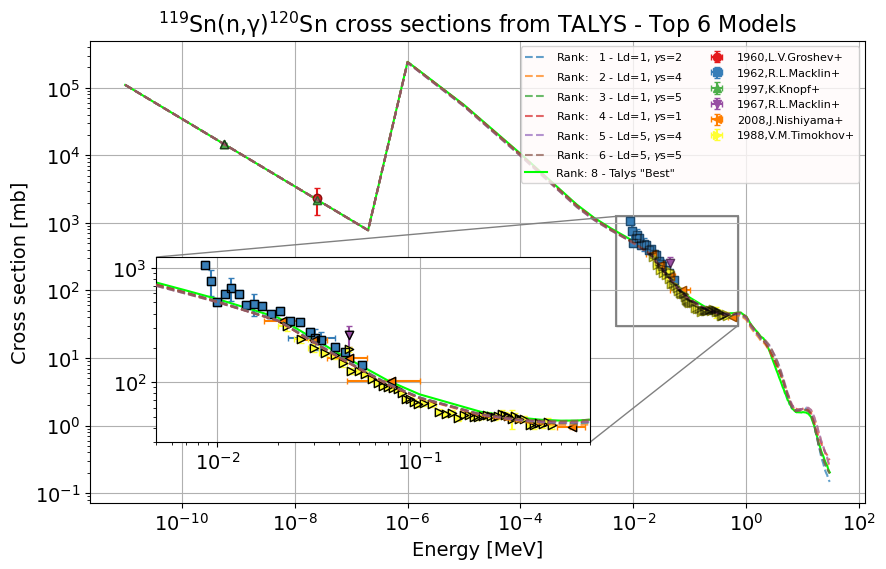

In [453]:
n = 6
for rank, model in enumerate(mse_rankings[: n], start=1):
    d = model['d']
    s = model['s']
    E = Sn120_n_γ_varying_models_data[d][s]['E']
    CS = Sn120_n_γ_varying_models_data[d][s]['CS']
    plt.plot(E, CS, label=f'Rank:{rank:>4} - Ld={d}, $γ$s={s}', alpha=0.7, linestyle='--', zorder=3)

plt.plot(E_best, CS_best, label=f'Rank: {talys_best_model_rank} - Talys "Best"', color='lime', zorder=2)
plot_exfor_data(Sn119_n_γ_exfor_data, border_alpha=0.4)

plt.semilogx()
plt.semilogy()

plt.xlabel('Energy [MeV]')
plt.ylabel('Cross section [mb]')

plt.title(f"{r"$^{119}$Sn(n,γ)$^{120}$Sn"} cross sections from TALYS - Top {n} Models")
plt.legend(ncols=2, fontsize=8, loc='upper right')


# Region to zoom
x0, x1 = 5e-3, 7e-1
y0, y1 = 3e1, 1.25e3

# Draw zoom box on main axes
rect = Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec='gray', lw=1.5, alpha=0.9)
ax = plt.gca()
ax.add_patch(rect)

axins = inset_axes(ax, width="40%", height="40%", loc="upper left", bbox_to_anchor=(0.075, -0.45, 1.4, 1), bbox_transform=ax.transAxes)

# ------------------ Begin Inner Plot ------------------
plt.sca(axins)

plot_exfor_data(Sn119_n_γ_exfor_data)
for rank, model in enumerate(mse_rankings[: n], start=1):
    d = model['d']
    s = model['s']
    E = Sn120_n_γ_varying_models_data[d][s]['E']
    CS = Sn120_n_γ_varying_models_data[d][s]['CS']
    plt.plot(E, CS, label=f'Rank:{rank:>4} - Ld={d}, $γ$s={s}', alpha=0.7, linestyle='--', zorder=3)
    
plt.plot(E_best, CS_best, label=f'Rank: {talys_best_model_rank} - Talys "Best"', color='lime', zorder=2)

axins.set_xscale('log')
axins.set_yscale('log')
axins.set_xlim(x0, x1)
axins.set_ylim(y0, y1)
axins.grid(True)

plt.sca(ax)
# ------------------- End Inner Plot -------------------


# Connector lines
mark_inset(ax, axins, loc1=2, loc2=4, fc='none', ec='gray', lw=1)


plt.savefig(f'Sn119_n_gamma_cross_section_top_{n}_models_with_exfor')
plt.show()